# 🏃 Phase 1: Complete Human Activity Recognition (HAR) Training
## All Sensor Combinations: Phone + Watch × Accelerometer + Gyroscope

**Project:** Goal-Aware, Activity-Driven Personalized Nutrition Recommendation System

This notebook trains activity recognition models for **ALL** sensor combinations:

| # | Device | Sensor | Model Name |
|---|--------|--------|------------|
| 1 | Phone | Accelerometer | `har_phone_accel` |
| 2 | Phone | Gyroscope | `har_phone_gyro` |
| 3 | Watch | Accelerometer | `har_watch_accel` |
| 4 | Watch | Gyroscope | `har_watch_gyro` |

---

In [1]:
# Run the setup notebook first
%run colab_setup.ipynb

Successfully connected to local path: c:\Users\joshw\OneDrive\Desktop\FYP_Work
📁 Configured Paths:
   Dataset Root: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset
   Models: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models
   Phone Accel: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/phone/accel
   Phone Gyro: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/phone/gyro
   Watch Accel: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/watch/accel
   Watch Gyro: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/watch/gyro
All libraries imported successfully!

 Package Versions:
   NumPy: 2.4.1
   Pandas: 2.3.3
   XGBoost: 3.1.3
   LightGBM: 4.6.0
   SHAP: 0.50.0
WISDM Activity Labels:
   ⭐ A: Walking
   ⭐ B: Jogging
      C: Stairs
   ⭐ D: Sitting
   ⭐ E: Standing
      F: Typing
      G: Brushing Teeth
      H: Eating Soup
      I: Eating Chips
      J: Eating Pasta
      K: Drinking
      L: Ea

## 1. 📊 Load All WISDM Data

In [2]:
# Load all WISDM data
wisdm_data = load_all_wisdm_data()

# Filter to primary activities (Walking, Jogging, Sitting, Standing)
PRIMARY_ACTIVITIES = ['A', 'B', 'D', 'E']

def filter_primary_activities(data):
    filtered = {}
    for key, df in data.items():
        if not df.empty:
            filtered[key] = df[df['activity'].isin(PRIMARY_ACTIVITIES)].copy()
    return filtered

primary_data = filter_primary_activities(wisdm_data)

print("\n📊 Primary Activities Data Summary:")
print("="*60)
for key, df in primary_data.items():
    if not df.empty:
        print(f"\n{key.upper()}:")
        print(f"   Total samples: {len(df):,}")
        print(f"   Subjects: {df['subject_id'].nunique()}")
        print(f"   Activities: {dict(df['activity'].value_counts())}")

Loading WISDM Dataset...



Loading watch gyro: 100%|██████████| 51/51 [00:07<00:00,  6.48it/s]



Data Loading Complete!

Dataset Summary:
   phone_accel: 4,804,403 samples, 51 subjects
   phone_gyro: 3,608,635 samples, 51 subjects
   watch_accel: 3,777,046 samples, 51 subjects
   watch_gyro: 3,440,342 samples, 51 subjects

📊 Primary Activities Data Summary:

PHONE_ACCEL:
   Total samples: 1,082,422
   Subjects: 51
   Activities: {'A': np.int64(279817), 'E': np.int64(269604), 'B': np.int64(268409), 'D': np.int64(264592)}

PHONE_GYRO:
   Total samples: 808,892
   Subjects: 51
   Activities: {'A': np.int64(203919), 'D': np.int64(202370), 'E': np.int64(202351), 'B': np.int64(200252)}

WATCH_ACCEL:
   Total samples: 845,829
   Subjects: 51
   Activities: {'E': np.int64(216529), 'D': np.int64(213018), 'A': np.int64(210495), 'B': np.int64(205787)}

WATCH_GYRO:
   Total samples: 769,517
   Subjects: 51
   Activities: {'D': np.int64(195050), 'E': np.int64(194103), 'A': np.int64(192531), 'B': np.int64(187833)}


## 2. 🔧 Training Pipeline Function

A reusable function to train models for any sensor data.

In [3]:
def train_har_pipeline(df, sensor_name, window_size=200, step_size=100):
    """
    Complete HAR training pipeline for a single sensor.
    
    Args:
        df: DataFrame with sensor data
        sensor_name: Name for saving (e.g., 'phone_accel')
        window_size: Samples per window
        step_size: Step between windows
        
    Returns:
        Dictionary with training results
    """
    print(f"\n{'='*60}")
    print(f"🎯 TRAINING: {sensor_name.upper()}")
    print(f"{'='*60}")
    
    if df.empty:
        print(f"⚠️ No data available for {sensor_name}")
        return None
    
    # Step 1: Create sliding windows
    print(f"\n📊 Step 1: Creating sliding windows...")
    windows, labels, subjects = create_sliding_windows(df, window_size, step_size)
    print(f"   Windows created: {len(windows)}")
    print(f"   Window shape: {windows.shape}")
    
    if len(windows) == 0:
        print(f"⚠️ No windows created for {sensor_name}")
        return None
    
    # Step 2: Extract features
    print(f"\n🔧 Step 2: Extracting features...")
    X = extract_features(windows)
    print(f"   Feature matrix: {X.shape}")
    
    # Handle NaN/Inf
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)
    
    # Step 3: Encode labels
    le = LabelEncoder()
    y = le.fit_transform(labels)
    print(f"   Classes: {le.classes_}")
    print(f"   Class distribution: {dict(zip(le.classes_, np.bincount(y)))}")
    
    # Step 4: Subject-wise train/test split
    print(f"\n📂 Step 3: Subject-wise train/test split...")
    unique_subjects = np.unique(subjects)
    train_subjects, test_subjects = train_test_split(
        unique_subjects, test_size=0.2, random_state=42
    )
    
    train_mask = np.isin(subjects, train_subjects)
    test_mask = np.isin(subjects, test_subjects)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    print(f"   Train: {len(X_train)} samples ({len(train_subjects)} subjects)")
    print(f"   Test: {len(X_test)} samples ({len(test_subjects)} subjects)")
    
    # Step 5: Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Step 6: Train models
    print(f"\n🤖 Step 4: Training models...")
    models = {
        'RandomForest': RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            random_state=42, use_label_encoder=False,
            eval_metric='mlogloss', n_jobs=-1
        ),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            random_state=42, n_jobs=-1, verbose=-1
        )
    }
    
    results = {}
    for name, model in models.items():
        print(f"   Training {name}...", end=" ")
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results[name] = {
            'model': model,
            'accuracy': acc,
            'f1': f1,
            'predictions': y_pred
        }
        print(f"Acc: {acc:.4f}, F1: {f1:.4f}")
    
    # Step 7: Select best model
    best_name = max(results, key=lambda x: results[x]['f1'])
    best_model = results[best_name]['model']
    best_acc = results[best_name]['accuracy']
    best_f1 = results[best_name]['f1']
    
    print(f"\n🏆 Best Model: {best_name} (F1: {best_f1:.4f})")
    
    # Step 8: Save model
    print(f"\n💾 Step 5: Saving model...")
    model_dir = f'har_{sensor_name}'
    save_model(best_model, model_dir, scaler, le)
    
    # Save feature names
    feature_names = list(X.columns)
    joblib.dump(feature_names, os.path.join(MODELS_PATH, model_dir, 'feature_names.joblib'))
    
    # Save training config
    config = {
        'sensor_name': sensor_name,
        'best_model': best_name,
        'accuracy': best_acc,
        'f1_score': best_f1,
        'classes': list(le.classes_),
        'class_names': [ACTIVITY_LABELS.get(c, c) for c in le.classes_],
        'n_features': len(feature_names),
        'window_size': window_size,
        'step_size': step_size,
        'n_train_samples': len(X_train),
        'n_test_samples': len(X_test),
        'all_results': {k: {'accuracy': v['accuracy'], 'f1': v['f1']} 
                       for k, v in results.items()}
    }
    joblib.dump(config, os.path.join(MODELS_PATH, model_dir, 'training_config.joblib'))
    
    print(f"\n✅ Training complete for {sensor_name}!")
    
    return {
        'sensor_name': sensor_name,
        'best_model_name': best_name,
        'best_model': best_model,
        'accuracy': best_acc,
        'f1': best_f1,
        'scaler': scaler,
        'label_encoder': le,
        'feature_names': feature_names,
        'X_test': X_test_scaled,
        'y_test': y_test,
        'y_pred': results[best_name]['predictions'],
        'all_results': results
    }

## 3. 🚀 Train All Sensor Models

In [4]:
# Dictionary to store all training results
all_sensor_results = {}

# Define sensor configurations
sensor_configs = [
    ('phone_accel', primary_data.get('phone_accel', pd.DataFrame())),
    ('phone_gyro', primary_data.get('phone_gyro', pd.DataFrame())),
    ('watch_accel', primary_data.get('watch_accel', pd.DataFrame())),
    ('watch_gyro', primary_data.get('watch_gyro', pd.DataFrame())),
]

In [5]:
# Train model for Phone Accelerometer
result = train_har_pipeline(sensor_configs[0][1], sensor_configs[0][0])
if result:
    all_sensor_results['phone_accel'] = result


🎯 TRAINING: PHONE_ACCEL

📊 Step 1: Creating sliding windows...
   Windows created: 10518
   Window shape: (10518, 200, 3)

🔧 Step 2: Extracting features...


Extracting features: 100%|██████████| 10518/10518 [00:41<00:00, 252.60it/s]


   Feature matrix: (10518, 58)
   Classes: ['A' 'B' 'D' 'E']
   Class distribution: {np.str_('A'): np.int64(2721), np.str_('B'): np.int64(2611), np.str_('D'): np.int64(2567), np.str_('E'): np.int64(2619)}

📂 Step 3: Subject-wise train/test split...
   Train: 8504 samples (40 subjects)
   Test: 2014 samples (11 subjects)

🤖 Step 4: Training models...
   Training RandomForest... Acc: 0.8942, F1: 0.8935
   Training XGBoost... Acc: 0.8813, F1: 0.8802
   Training LightGBM... Acc: 0.8972, F1: 0.8966

🏆 Best Model: LightGBM (F1: 0.8966)

💾 Step 5: Saving model...
✅ Model saved to: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models\har_phone_accel

✅ Training complete for phone_accel!


In [6]:
# Train model for Phone Gyroscope
result = train_har_pipeline(sensor_configs[1][1], sensor_configs[1][0])
if result:
    all_sensor_results['phone_gyro'] = result


🎯 TRAINING: PHONE_GYRO

📊 Step 1: Creating sliding windows...
   Windows created: 7768
   Window shape: (7768, 200, 3)

🔧 Step 2: Extracting features...


Extracting features: 100%|██████████| 7768/7768 [00:30<00:00, 251.79it/s]


   Feature matrix: (7768, 58)
   Classes: ['A' 'B' 'D' 'E']
   Class distribution: {np.str_('A'): np.int64(1959), np.str_('B'): np.int64(1925), np.str_('D'): np.int64(1942), np.str_('E'): np.int64(1942)}

📂 Step 3: Subject-wise train/test split...
   Train: 6120 samples (40 subjects)
   Test: 1648 samples (11 subjects)

🤖 Step 4: Training models...
   Training RandomForest... Acc: 0.8101, F1: 0.8099
   Training XGBoost... Acc: 0.8046, F1: 0.8042
   Training LightGBM... Acc: 0.7979, F1: 0.7975

🏆 Best Model: RandomForest (F1: 0.8099)

💾 Step 5: Saving model...
✅ Model saved to: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models\har_phone_gyro

✅ Training complete for phone_gyro!


In [7]:
# Train model for Watch Accelerometer
result = train_har_pipeline(sensor_configs[2][1], sensor_configs[2][0])
if result:
    all_sensor_results['watch_accel'] = result


🎯 TRAINING: WATCH_ACCEL

📊 Step 1: Creating sliding windows...
   Windows created: 8227
   Window shape: (8227, 200, 3)

🔧 Step 2: Extracting features...


Extracting features: 100%|██████████| 8227/8227 [00:32<00:00, 252.80it/s]


   Feature matrix: (8227, 58)
   Classes: ['A' 'B' 'D' 'E']
   Class distribution: {np.str_('A'): np.int64(2049), np.str_('B'): np.int64(2003), np.str_('D'): np.int64(2069), np.str_('E'): np.int64(2106)}

📂 Step 3: Subject-wise train/test split...
   Train: 6481 samples (40 subjects)
   Test: 1746 samples (11 subjects)

🤖 Step 4: Training models...
   Training RandomForest... Acc: 0.8540, F1: 0.8515
   Training XGBoost... Acc: 0.8677, F1: 0.8663
   Training LightGBM... Acc: 0.8625, F1: 0.8617

🏆 Best Model: XGBoost (F1: 0.8663)

💾 Step 5: Saving model...
✅ Model saved to: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models\har_watch_accel

✅ Training complete for watch_accel!


In [8]:
# Train model for Watch Gyroscope
result = train_har_pipeline(sensor_configs[3][1], sensor_configs[3][0])
if result:
    all_sensor_results['watch_gyro'] = result


🎯 TRAINING: WATCH_GYRO

📊 Step 1: Creating sliding windows...
   Windows created: 7438
   Window shape: (7438, 200, 3)

🔧 Step 2: Extracting features...


Extracting features: 100%|██████████| 7438/7438 [00:29<00:00, 254.22it/s]


   Feature matrix: (7438, 58)
   Classes: ['A' 'B' 'D' 'E']
   Class distribution: {np.str_('A'): np.int64(1861), np.str_('B'): np.int64(1813), np.str_('D'): np.int64(1886), np.str_('E'): np.int64(1878)}

📂 Step 3: Subject-wise train/test split...
   Train: 5918 samples (40 subjects)
   Test: 1520 samples (11 subjects)

🤖 Step 4: Training models...
   Training RandomForest... Acc: 0.8947, F1: 0.8943
   Training XGBoost... Acc: 0.8908, F1: 0.8906
   Training LightGBM... Acc: 0.9020, F1: 0.9019

🏆 Best Model: LightGBM (F1: 0.9019)

💾 Step 5: Saving model...
✅ Model saved to: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models\har_watch_gyro

✅ Training complete for watch_gyro!


## 4. 📊 Compare All Sensors

In [9]:
# Create comparison table
comparison_data = []
for sensor_name, result in all_sensor_results.items():
    comparison_data.append({
        'Sensor': sensor_name.replace('_', ' ').title(),
        'Best Model': result['best_model_name'],
        'Accuracy': result['accuracy'],
        'F1 Score': result['f1']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1 Score', ascending=False)

print("\n" + "="*70)
print("📊 SENSOR COMPARISON SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


📊 SENSOR COMPARISON SUMMARY
     Sensor   Best Model  Accuracy  F1 Score
 Watch Gyro     LightGBM  0.901974  0.901886
Phone Accel     LightGBM  0.897219  0.896554
Watch Accel      XGBoost  0.867698  0.866262
 Phone Gyro RandomForest  0.810073  0.809908


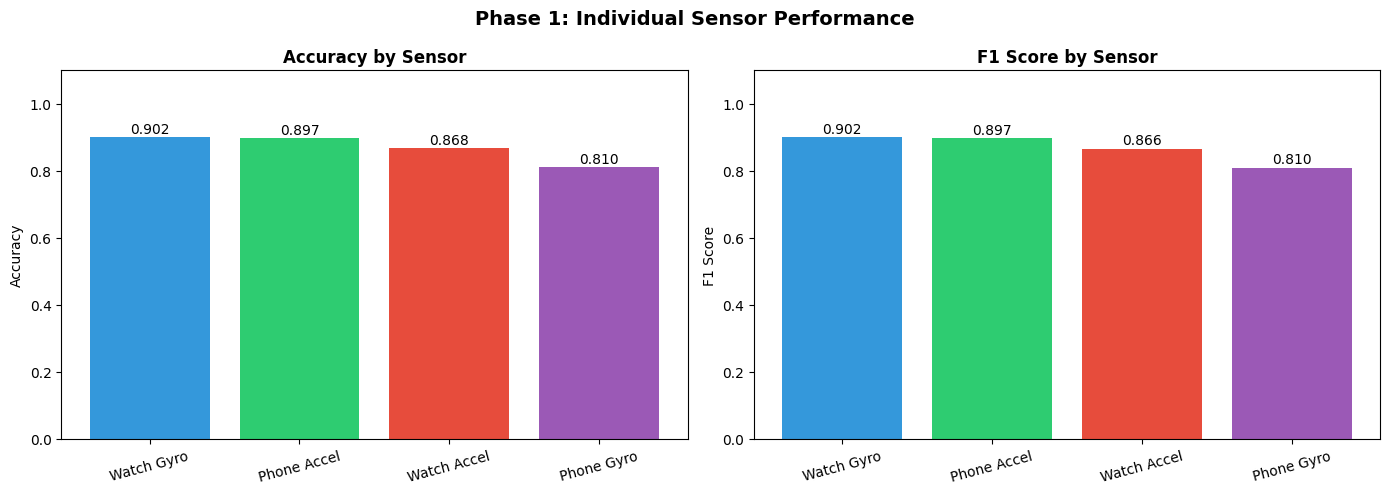

In [10]:
# Visualization: Sensor Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1 = axes[0]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars1 = ax1.bar(comparison_df['Sensor'], comparison_df['Accuracy'], color=colors)
ax1.set_title('Accuracy by Sensor', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='x', rotation=15)
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center')

# F1 Score comparison
ax2 = axes[1]
bars2 = ax2.bar(comparison_df['Sensor'], comparison_df['F1 Score'], color=colors)
ax2.set_title('F1 Score by Sensor', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1 Score')
ax2.set_ylim(0, 1.1)
ax2.tick_params(axis='x', rotation=15)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center')

plt.suptitle('Phase 1: Individual Sensor Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, 'sensor_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. 📈 Detailed Results per Sensor

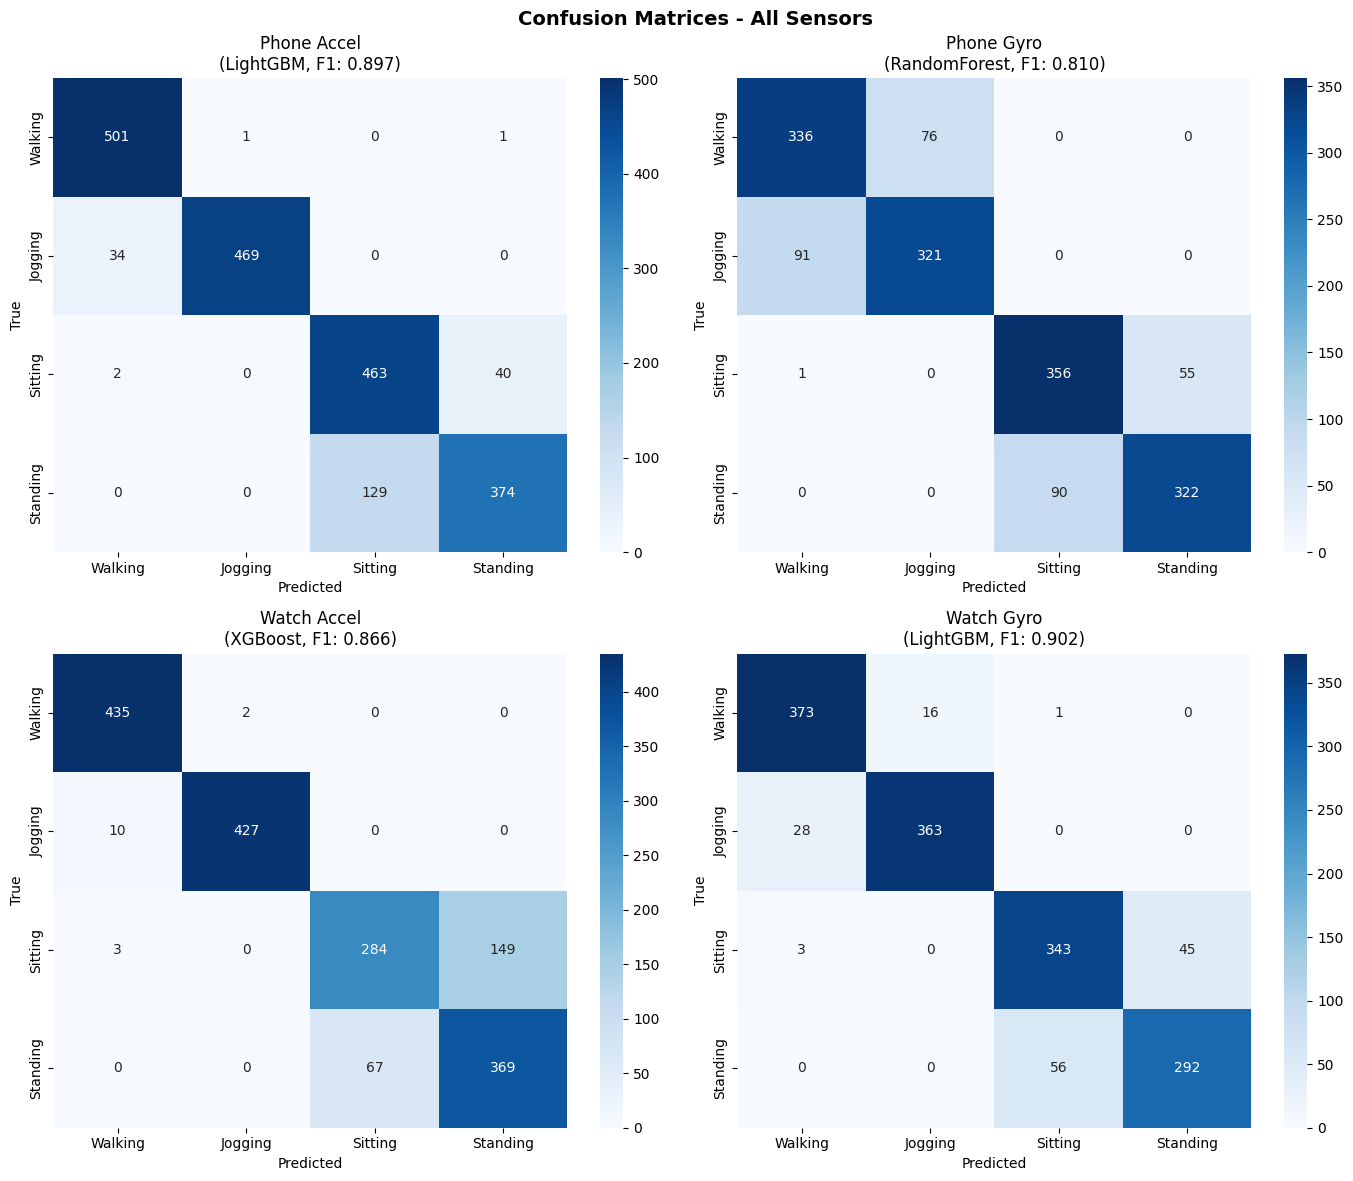

In [11]:
# Confusion matrices for all sensors
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (sensor_name, result) in enumerate(all_sensor_results.items()):
    ax = axes[idx]
    
    cm = confusion_matrix(result['y_test'], result['y_pred'])
    class_names = [ACTIVITY_LABELS.get(c, c) for c in result['label_encoder'].classes_]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f"{sensor_name.replace('_', ' ').title()}\n({result['best_model_name']}, F1: {result['f1']:.3f})")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices - All Sensors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, 'confusion_matrices_all.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Classification reports
for sensor_name, result in all_sensor_results.items():
    print(f"\n{'='*60}")
    print(f"📋 CLASSIFICATION REPORT: {sensor_name.upper()}")
    print(f"{'='*60}")
    class_names = [ACTIVITY_LABELS.get(c, c) for c in result['label_encoder'].classes_]
    print(classification_report(result['y_test'], result['y_pred'], target_names=class_names))


📋 CLASSIFICATION REPORT: PHONE_ACCEL
              precision    recall  f1-score   support

     Walking       0.93      1.00      0.96       503
     Jogging       1.00      0.93      0.96       503
     Sitting       0.78      0.92      0.84       505
    Standing       0.90      0.74      0.81       503

    accuracy                           0.90      2014
   macro avg       0.90      0.90      0.90      2014
weighted avg       0.90      0.90      0.90      2014


📋 CLASSIFICATION REPORT: PHONE_GYRO
              precision    recall  f1-score   support

     Walking       0.79      0.82      0.80       412
     Jogging       0.81      0.78      0.79       412
     Sitting       0.80      0.86      0.83       412
    Standing       0.85      0.78      0.82       412

    accuracy                           0.81      1648
   macro avg       0.81      0.81      0.81      1648
weighted avg       0.81      0.81      0.81      1648


📋 CLASSIFICATION REPORT: WATCH_ACCEL
              pre

## 6. 🔍 SHAP Explainability (Best Sensor)

In [13]:
# Find best performing sensor
best_sensor = max(all_sensor_results, key=lambda x: all_sensor_results[x]['f1'])
best_result = all_sensor_results[best_sensor]

print(f"🏆 Best Overall Sensor: {best_sensor.upper()}")
print(f"   Model: {best_result['best_model_name']}")
print(f"   F1 Score: {best_result['f1']:.4f}")

🏆 Best Overall Sensor: WATCH_GYRO
   Model: LightGBM
   F1 Score: 0.9019


In [14]:
# SHAP analysis for best sensor
print(f"\n🔍 Computing SHAP values for {best_sensor}...")

sample_size = min(300, len(best_result['X_test']))
X_sample = best_result['X_test'][:sample_size]

explainer = shap.TreeExplainer(best_result['best_model'])
shap_values = explainer.shap_values(X_sample)

# 1. Standardize shap_values to be a list or array
# (Some versions of SHAP return a list for multiclass, others a 3D array)

# Case A: List of arrays (e.g., Random Forest, some XGBoost versions)
if isinstance(shap_values, list):
    # Average absolute SHAP values across all classes
    # Result: (samples x features)
    shap_mean_matrix = np.mean([np.abs(sv) for sv in shap_values], axis=0)

# Case B: 3D Array (samples x features x classes)
elif len(shap_values.shape) == 3:
    # Average absolute SHAP values across the last dimension (classes)
    # Result: (samples x features)
    shap_mean_matrix = np.mean(np.abs(shap_values), axis=-1)

# Case C: 2D Array (Binary classification or Regression)
else:
    # Result: (samples x features)
    shap_mean_matrix = np.abs(shap_values)

# 2. Calculate global feature importance (1D array: one value per feature)
# Average across all samples (axis 0)
feature_importance_values = np.mean(shap_mean_matrix, axis=0)

# Feature importance
feature_importance = pd.DataFrame({
    'feature': best_result['feature_names'],
    'importance': feature_importance_values
}).sort_values('importance', ascending=False)

print(f"\n📊 Top 15 Features ({best_sensor}):")
print(feature_importance.head(15).to_string(index=False))


🔍 Computing SHAP values for watch_gyro...

📊 Top 15 Features (watch_gyro):
         feature  importance
           y_iqr    0.818789
         mag_min    0.625257
           z_mad    0.554403
           z_iqr    0.534292
           y_mad    0.424567
         yz_corr    0.333061
       y_fft_max    0.290493
           y_min    0.284866
x_zero_crossings    0.180017
           x_iqr    0.173065
z_zero_crossings    0.167701
y_zero_crossings    0.154604
   x_fft_entropy    0.147739
       z_fft_max    0.107878
   z_fft_entropy    0.105885


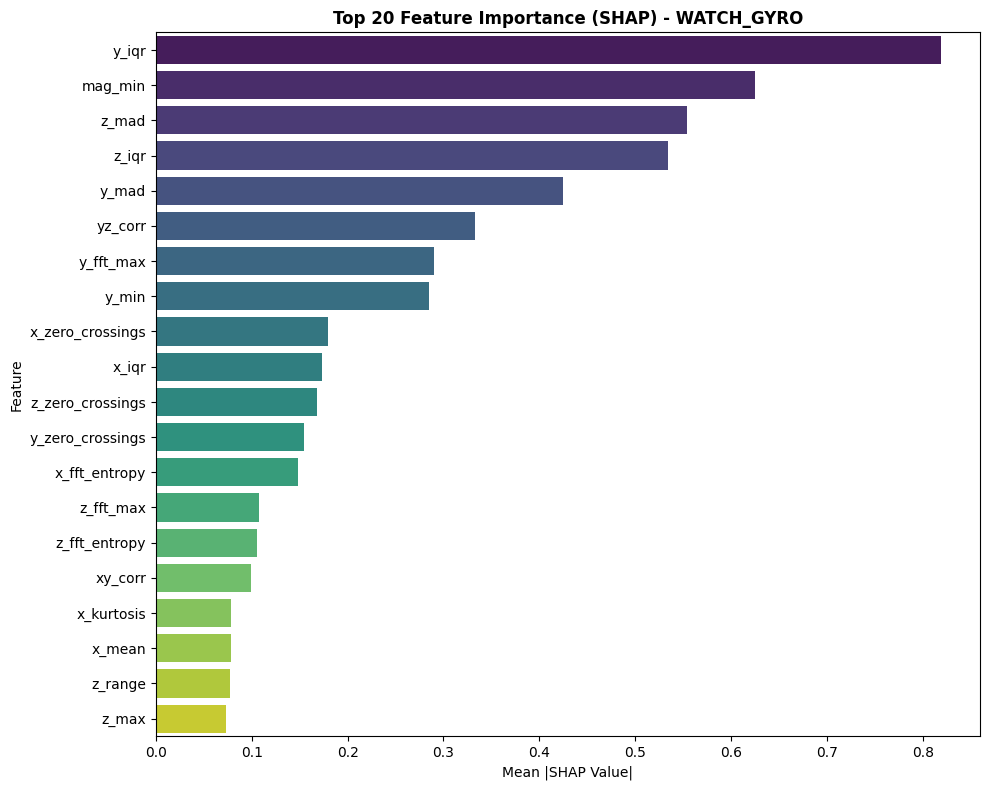

In [15]:
# Plot SHAP feature importance
plt.figure(figsize=(10, 8))
top_n = 20
top_features = feature_importance.head(top_n)

sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title(f'Top {top_n} Feature Importance (SHAP) - {best_sensor.upper()}', fontweight='bold')
plt.xlabel('Mean |SHAP Value|')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, f'shap_importance_{best_sensor}.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. 💾 Save Final Summary

In [16]:
# Save overall Phase 1 summary
phase1_summary = {
    'best_sensor': best_sensor,
    'best_sensor_f1': best_result['f1'],
    'best_sensor_model': best_result['best_model_name'],
    'all_sensors': {
        name: {
            'best_model': r['best_model_name'],
            'accuracy': r['accuracy'],
            'f1_score': r['f1']
        }
        for name, r in all_sensor_results.items()
    },
    'activities': PRIMARY_ACTIVITIES,
    'activity_names': [ACTIVITY_LABELS.get(a, a) for a in PRIMARY_ACTIVITIES]
}

joblib.dump(phase1_summary, os.path.join(MODELS_PATH, 'phase1_summary.joblib'))

print("\n" + "="*70)
print("🎉 PHASE 1 COMPLETE: Individual Sensor Models")
print("="*70)
print(f"\nBest Sensor: {best_sensor.upper()}")
print(f"Best Model: {best_result['best_model_name']}")
print(f"Best F1 Score: {best_result['f1']:.4f}")
print(f"\nSaved Models:")
for sensor in all_sensor_results.keys():
    print(f"   ✅ {MODELS_PATH}/har_{sensor}/")
print(f"\nNext Step: Run sensor fusion notebook for combined phone+watch model")
print("="*70)


🎉 PHASE 1 COMPLETE: Individual Sensor Models

Best Sensor: WATCH_GYRO
Best Model: LightGBM
Best F1 Score: 0.9019

Saved Models:
   ✅ c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models/har_phone_accel/
   ✅ c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models/har_phone_gyro/
   ✅ c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models/har_watch_accel/
   ✅ c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models/har_watch_gyro/

Next Step: Run sensor fusion notebook for combined phone+watch model


---
## 📋 Models Saved

```
Models/
├── har_phone_accel/
│   ├── model.joblib
│   ├── scaler.joblib
│   ├── label_encoder.joblib
│   ├── feature_names.joblib
│   └── training_config.joblib
├── har_phone_gyro/
│   └── ...
├── har_watch_accel/
│   └── ...
├── har_watch_gyro/
│   └── ...
├── phase1_summary.joblib
├── sensor_comparison.png
├── confusion_matrices_all.png
└── shap_importance_*.png
```

---
*Phase 1 Complete - Proceed to Sensor Fusion*